1)Load necessary libraries like pandas, matplotlib, seaborn, and clustering modules from sklearn and sklearn_extra.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder

from sklearn.cluster import KMeans
from sklearn_extra.cluster import KMedoids

2)Read the StudentsPerformance.csv file using pandas.

In [1]:
#github id: github.com/h-240407/iat
#filename: StudentsPerformance

In [2]:
data=pd.read_csv("StudentsPerformance.csv")
print(data)

   gender race parental_education         lunch test_preparation  math_score  \
0  female    A           bachelor      standard             none          72   
1  female    B            college      standard        completed          69   
2    male    C             master  free/reduced             none          90   
3    male    A          associate      standard             none          47   
4  female    C            college      standard        completed          76   
5    male    B        high_school  free/reduced             none          71   
6  female    A             master      standard        completed          88   
7    male    C            college      standard             none          40   
8  female    B           bachelor  free/reduced        completed          64   
9    male    A            college      standard             none          58   

   reading_score  writing_score  
0             72             74  
1             90             88  
2             95 

3)Display the first few rows, data types, summary statistics, and check for missing values.

In [ ]:
print(data.head(5).info())

4)Use seaborn to generate a pairplot for visual exploration of relationships between features.

In [ ]:
sns.pairplot(data[["math_score","reading_score","writing_score"]])

5)Convert categorical data to numerical using encoding (e.g., LabelEncoder or OneHotEncoder).

In [ ]:
encoder=LabelEncoder()
data["gender"] = encoder.fit_transform(data["gender"])
data["race"] = encoder.fit_transform(data["race"])
data["parental_education"] = encoder.fit_transform(data["parental_education"])
data["lunch"] = encoder.fit_transform(data["lunch"])
data["test_preparation"] = encoder.fit_transform(data["test_preparation"])
print(data.head())

6)Select relevant features (X) for clustering.

In [6]:
X=data[["math_score","reading_score","writing_score"]]

7)Use the KMeans class to cluster data and assign cluster labels.

In [7]:
kmeans = KMeans(
    n_clusters=3, #cluster the data in 3 grp 
    random_state=42
)

data["KMeans_Cluster"] = kmeans.fit_predict(X)

print(data)

   gender  race  parental_education  lunch  test_preparation  math_score  \
0       0     0                   1      1                 1          72   
1       0     1                   2      1                 0          69   
2       1     2                   4      0                 1          90   
3       1     0                   0      1                 1          47   
4       0     2                   2      1                 0          76   
5       1     1                   3      0                 1          71   
6       0     0                   4      1                 0          88   
7       1     2                   2      1                 1          40   
8       0     1                   1      0                 0          64   
9       1     0                   2      1                 1          58   

   reading_score  writing_score  KMeans_Cluster  
0             72             74               1  
1             90             88               1  
2            

8)Plot the clusters and centroids for visual understanding.

Text(0.5, 1.0, 'K-Means Clustering')

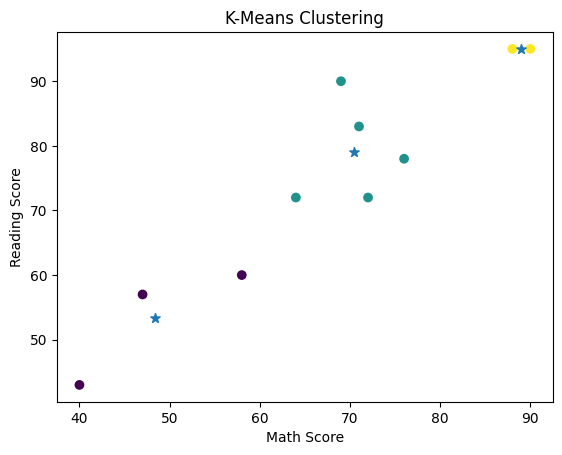

In [20]:
plt.scatter(
    X["math_score"],
    X["reading_score"],
    c=data["KMeans_Cluster"]
)
plt.scatter(
    kmeans.cluster_centers_[:,0],
    kmeans.cluster_centers_[:,1],
    s=50,
    marker="*"
)
plt.xlabel("Math Score")
plt.ylabel("Reading Score")
plt.title("K-Means Clustering")

9)Use KMedoids from sklearn_extra.cluster to perform clustering.

In [12]:
kmedoids = KMedoids(
    n_clusters=3, #cluster the data in 3 grp 
    random_state=42
)

data["KMedoids_Cluster"] = kmedoids.fit_predict(X)

print(data)

   gender  race  parental_education  lunch  test_preparation  math_score  \
0       0     0                   1      1                 1          72   
1       0     1                   2      1                 0          69   
2       1     2                   4      0                 1          90   
3       1     0                   0      1                 1          47   
4       0     2                   2      1                 0          76   
5       1     1                   3      0                 1          71   
6       0     0                   4      1                 0          88   
7       1     2                   2      1                 1          40   
8       0     1                   1      0                 0          64   
9       1     0                   2      1                 1          58   

   reading_score  writing_score  KMeans_Cluster  KMedoids_Cluster  
0             72             74               1                 1  
1             90           

10)Plot K-Medoids Cluster

Text(0.5, 1.0, 'K-Medoids Clustering')

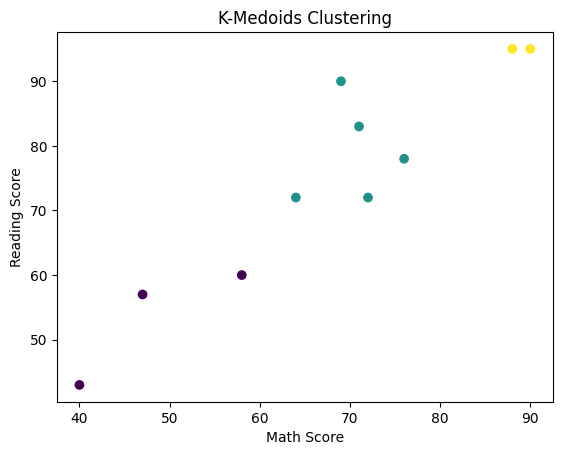

In [16]:
plt.scatter(
    X["math_score"],
    X["reading_score"],
    c=data["KMedoids_Cluster"]
)

plt.xlabel("Math Score")
plt.ylabel("Reading Score")

plt.title("K-Medoids Clustering")

10)Display the clusters formed by K-Medoids for comparison with K-Means.

In [18]:
print(data[["KMeans_Cluster",
            "KMedoids_Cluster"]])

   KMeans_Cluster  KMedoids_Cluster
0               1                 1
1               1                 1
2               2                 2
3               0                 0
4               1                 1
5               1                 1
6               2                 2
7               0                 0
8               1                 1
9               0                 0
